# Figure 17 -- reconstruction quality

Loads `bench/results/density_reconstruction/reconstruction_runs.json`, produced by `bench/payoff_static/reconstruction_runs.py`. No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.RESULTS_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


wrote /export/home/tbuck/jaccpot-payoff-wt/bench/results/figures/fig17_reconstruction_quality.pdf


'/export/home/tbuck/jaccpot-payoff-wt/bench/results/figures/fig17_reconstruction_quality.pdf'

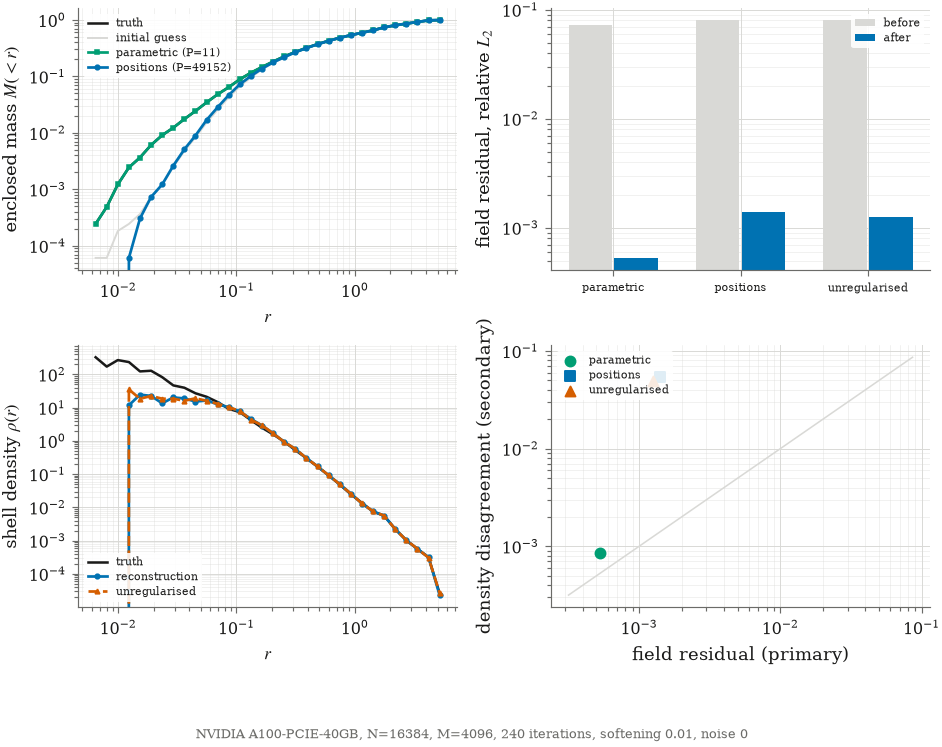

In [2]:
art = jsonio.read_result("density_reconstruction/reconstruction_runs.json")
cfg, recs = art["config"], art["data"]["records"]
recs = [r for r in recs if not r.get("failed")]
if not recs:
    raise SystemExit("reconstruction_runs.json has no successful rows")

def pick(**want):
    for r in recs:
        if all(r.get(k) == v for k, v in want.items()):
            return r
    return None

ref = dict(initial_guess="perturbed_truth", noise_fraction=cfg["noise_fractions"][0],
           softening=cfg["softenings"][0], perturber="lmc_like", regularized=True)
high = pick(parameterization="positions", **ref)
low = pick(parameterization="parametric", **ref)
unreg = pick(parameterization="positions", **{**ref, "regularized": False})
if high is None:
    raise SystemExit("no reference high-dimensional run in the artifact")

fig, axes = style.figure(width=style.TWO_COL, height=5.0, ncols=2, nrows=2)

# (a) enclosed mass: truth vs parametric vs high-dimensional -------------- #
ax = axes[0][0]
prof = high["profile_truth"]
ax.plot(prof["radius"], prof["enclosed_mass"], color=style.INK, lw=1.3, label="truth")
ax.plot(high["profile_initial"]["radius"], high["profile_initial"]["enclosed_mass"],
        color=style.GRID, lw=1.0, label="initial guess")
if low is not None:
    ax.plot(low["profile_reconstructed"]["radius"],
            low["profile_reconstructed"]["enclosed_mass"],
            marker=style.MARKERS[1], ms=2.4, color=style.CATEGORICAL[0],
            label="parametric (P=%d)" % low["num_free_parameters"])
ax.plot(high["profile_reconstructed"]["radius"],
        high["profile_reconstructed"]["enclosed_mass"],
        marker=style.MARKERS[0], ms=2.4, color=style.ENTITY["positions"],
        label="positions (P=%d)" % high["num_free_parameters"])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$r$"); ax.set_ylabel("enclosed mass $M(<r)$")
style.finish(ax, legend=True, legend_kwargs={"loc": "upper left", "fontsize": 5.6})

# (b) field residual before/after, and the noise floor -------------------- #
ax = axes[0][1]
labels, before, after, floors = [], [], [], []
for label, run in (("parametric", low), ("positions", high), ("unregularised", unreg)):
    if run is None:
        continue
    labels.append(label)
    before.append(run["field_residual_before"]["rel_l2"])
    after.append(run["field_residual_after"]["rel_l2"])
    floors.append(run["field_residual_after"].get("noise_floor_rel_l2"))
x = np.arange(len(labels))
ax.bar(x - 0.18, before, width=0.34, color=style.GRID, label="before")
ax.bar(x + 0.18, after, width=0.34, color=style.ENTITY["positions"], label="after")
for i, floor in enumerate(floors):
    if floor:
        ax.plot([i - 0.4, i + 0.4], [floor, floor], color=style.CATEGORICAL[2],
                lw=1.0, ls="--", label="noise floor" if i == 0 else None)
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=5.8)
ax.set_ylabel("field residual, relative $L_2$")
style.finish(ax, legend=True, legend_kwargs={"loc": "upper right", "fontsize": 5.6})

# (c) shell density, truth vs reconstruction ------------------------------- #
ax = axes[1][0]
ax.plot(prof["radius"], prof["shell_density"], color=style.INK, lw=1.3, label="truth")
ax.plot(high["profile_reconstructed"]["radius"],
        high["profile_reconstructed"]["shell_density"],
        marker=style.MARKERS[0], ms=2.4, color=style.ENTITY["positions"],
        label="reconstruction")
if unreg is not None:
    ax.plot(unreg["profile_reconstructed"]["radius"],
            unreg["profile_reconstructed"]["shell_density"],
            marker=style.MARKERS[2], ms=2.4, ls="--", color=style.CATEGORICAL[2],
            label="unregularised")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$r$"); ax.set_ylabel(r"shell density $\rho(r)$")
style.finish(ax, legend=True, legend_kwargs={"loc": "lower left", "fontsize": 5.6})

# (d) the degeneracy, stated as numbers ----------------------------------- #
# Panel (d) is the unregularised run. What it must show is that the FIELD can be
# fitted while the DENSITY is not recovered -- so it plots both, per run, rather
# than a picture of particles that would invite the eye to judge by clumpiness.
ax = axes[1][1]
rows = [(l, r) for l, r in (("parametric", low), ("positions", high),
                            ("unregularised", unreg)) if r is not None]
fx = [r["field_residual_after"]["rel_l2"] for _, r in rows]
dx = [r["density_after"]["grid_rel_l2"] for _, r in rows]
for i, (label, _) in enumerate(rows):
    ax.scatter(fx[i], dx[i], marker=style.MARKERS[i], s=26,
               color=style.CATEGORICAL[i % len(style.CATEGORICAL)], label=label)
lim = [min(fx + dx) * 0.6, max(fx + dx) * 1.6]
ax.plot(lim, lim, color=style.GRID, lw=0.8, zorder=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("field residual (primary)")
ax.set_ylabel("density disagreement (secondary)")
style.finish(ax, legend=True, legend_kwargs={"loc": "upper left", "fontsize": 5.6})

fig.tight_layout()
style.footer(fig, "%s, N=%d, M=%d, %d iterations, softening %g, noise %g" % (
    art["meta"]["device_kind"], high["N"], high["M"], high["iterations"],
    high["softening"], high["noise_fraction"]))
style.save(fig, str(FIG_DIR / "fig17_reconstruction_quality.pdf"))


## Caption


Reconstruction quality. **(a)** Enclosed-mass profile: truth, the initial guess,
the parametric fit and the high-dimensional fit. **(b)** Field-space residual
before and after each fit, with the noise floor marked -- a residual at the
floor has extracted everything the data holds, and driving it lower is fitting
the noise realisation. **(c)** Shell density, including the deliberately
unregularised run. **(d)** The degeneracy stated quantitatively: field residual
against density disagreement, with the diagonal drawn. Points below the diagonal
have fitted the field better than they have recovered the density. This is the
section's central caveat and not an artefact -- recovering discrete source
positions from external field samples is strongly ill-posed and has continuous
degeneracies, so a small field residual is *not* evidence that the mass
distribution has been recovered. Per-particle position error is not shown: the
sources are equal-mass and therefore interchangeable, which makes it close to
meaningless.
